# 🤖 Chatbot Interaction Effectiveness — ML & Deep Learning Models
### HCI Research Projects | Systematic Literature Review Dataset (55 Papers)
---
**Models Applied:**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine (SVM)
6. Neural Network (MLP — Deep Learning)

**Target Variable:** `Satisfaction` (1 = satisfied, 0 = not satisfied)


In [1]:
# ── Step 1: Import Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, roc_auc_score, roc_curve,
                              classification_report, ConfusionMatrixDisplay)

# ML Models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neural_network  import MLPClassifier   # Deep Learning (MLP)

print('✅ All libraries imported successfully!')
print(f'   scikit-learn version: {__import__("sklearn").__version__}')

✅ All libraries imported successfully!
   scikit-learn version: 1.6.1


## Step 2: Load the Preprocessed Dataset

In [2]:
# Load binary-coded dataset
# Upload 'Chatbot_Binary_Dataset.xlsx' to your Colab session first
# (Files panel → Upload, or use the line below if running locally)

df = pd.read_excel('Chatbot_Binary_Dataset.xlsx',
                   sheet_name='Binary_Coded_Dataset',
                   header=1)

#  Preprocessing (already done ,re-applying for clean pipeline)
binary_cols = [c for c in df.columns if c not in ['Paper_ID', 'Year', 'Industry']]
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['Industry'].fillna('Unknown', inplace=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(df['Year'].median()).astype(int)

le = LabelEncoder()
df['Industry_Encoded'] = le.fit_transform(df['Industry'])

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(5)

✅ Dataset loaded: 55 rows × 25 columns


,Paper_ID,Year,Industry,Quantitative,Qualitative,Mixed,Small_Sample,Medium_Sample,Large_Sample,Response_Accuracy,...,Anthropomorphism,Trust,Privacy_Concern,Prior_Experience,Digital_Literacy,High_Task_Complexity,Sensitive_Industry,Satisfaction,Continued_Use,Industry_Encoded
0,P1,2026,E-Commerce,1,0,0,0,1,0,1,...,0,1,1,1,1,0,0,1,1,3
1,P2,2022,Banking,0,1,0,1,0,0,1,...,0,0,1,0,0,1,1,1,1,0
2,P3,2026,E-Commerce,0,1,0,1,0,0,1,...,1,1,1,1,1,1,0,1,1,3
3,P4,2025,General/NLP,1,0,0,0,0,1,1,...,0,0,0,0,0,1,0,0,0,6
4,P5,2025,Multi-domain,1,1,1,0,0,1,1,...,0,0,1,0,0,1,0,0,0,8


## Step 3: Define Features (X) and Target (y)

In [3]:
feature_cols = [
    'Response_Accuracy', 'Reliability', 'Personalization', 'Ease_of_Use',
    'Transparency', 'Social_Presence', 'Anthropomorphism', 'Trust',
    'Privacy_Concern', 'Prior_Experience', 'Digital_Literacy',
    'High_Task_Complexity', 'Sensitive_Industry',
    'Quantitative', 'Qualitative', 'Mixed',
    'Industry_Encoded', 'Year'
]

X = df[feature_cols].values
y = df['Satisfaction'].values

# Scale features (important for SVM and Neural Network)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% train / 20% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features      : {len(feature_cols)}')
print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]} samples')
print(f'Class balance : Satisfied={y.sum()}, Not Satisfied={len(y)-y.sum()}')

Features      : 18
Training set  : 44 samples
Test set      : 11 samples
Class balance : Satisfied=40, Not Satisfied=15


## Step 4: Define All Models

In [4]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=5, random_state=42, class_weight='balanced'),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),

    'SVM': SVC(
        kernel='rbf', probability=True, random_state=42, class_weight='balanced'),

    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15)
}

COLORS = {
    'Logistic Regression' : '#10B981',
    'Decision Tree'       : '#EF4444',
    'Random Forest'       : '#3B82F6',
    'Gradient Boosting'   : '#8B5CF6',
    'SVM'                 : '#14B8A6',
    'Neural Network (MLP)': '#F59E0B',
}

print(f'✅ {len(MODELS)} models defined:')
for name in MODELS:
    print(f'   • {name}')

✅ 6 models defined:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • SVM
   • Neural Network (MLP)


## Step 5: Train All Models & Collect Metrics

In [5]:
results = {}

for name, model in MODELS.items():
    print(f'Training: {name}...')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cm   = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model'    : model,
        'accuracy' : acc,
        'f1'       : f1,
        'precision': prec,
        'recall'   : rec,
        'auc'      : auc,
        'cv_mean'  : cv.mean(),
        'cv_std'   : cv.std(),
        'cm'       : cm,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
    }
    print(f'   ✅  Accuracy={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  CV={cv.mean():.3f}±{cv.std():.3f}')

best_model = max(results, key=lambda n: results[n]['accuracy'])
print(f'\n🏆 Best Model: {best_model}  (Accuracy = {results[best_model]["accuracy"]:.3f})')

Training: Logistic Regression...
   ✅  Accuracy=0.636  F1=0.656  AUC=0.542  CV=0.545±0.100
Training: Decision Tree...
   ✅  Accuracy=0.455  F1=0.455  AUC=0.312  CV=0.600±0.093
Training: Random Forest...
   ✅  Accuracy=0.727  F1=0.612  AUC=0.500  CV=0.709±0.068
Training: Gradient Boosting...
   ✅  Accuracy=0.636  F1=0.636  AUC=0.667  CV=0.691±0.045
Training: SVM...
   ✅  Accuracy=0.545  F1=0.513  AUC=0.458  CV=0.600±0.073
Training: Neural Network (MLP)...
   ✅  Accuracy=0.727  F1=0.738  AUC=0.708  CV=0.618±0.106

🏆 Best Model: Random Forest  (Accuracy = 0.727)


## Step 6: Metrics Summary Table

In [7]:
metrics_df = pd.DataFrame([
    {
        'Model'     : name,
        'Accuracy'  : f"{r['accuracy']:.4f}",
        'F1 Score'  : f"{r['f1']:.4f}",
        'Precision' : f"{r['precision']:.4f}",
        'Recall'    : f"{r['recall']:.4f}",
        'AUC'       : f"{r['auc']:.4f}",
        'CV Mean'   : f"{r['cv_mean']:.4f}",
        'CV Std'    : f"{r['cv_std']:.4f}",
    }
    for name, r in results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

metrics_df.index += 1
metrics_df.style.background_gradient(cmap='Blues', subset=['Accuracy','F1 Score','AUC'])\
           .set_caption('Model Performance Summary')

,Model,Accuracy,F1 Score,Precision,Recall,AUC,CV Mean,CV Std
1,Random Forest,0.7273,0.6124,0.5289,0.7273,0.5000,0.7091,0.0680
2,Neural Network (MLP),0.7273,0.7377,0.7597,0.7273,0.7083,0.6182,0.1060
3,Logistic Regression,0.6364,0.6558,0.7152,0.6364,0.5417,0.5455,0.0996
4,Gradient Boosting,0.6364,0.6364,0.6364,0.6364,0.6667,0.6909,0.0445
5,SVM,0.5455,0.5134,0.4848,0.5455,0.4583,0.6000,0.0727
6,Decision Tree,0.4545,0.4545,0.4545,0.4545,0.3125,0.6000,0.0927


## Step 7: Confusion Matrices — All Models

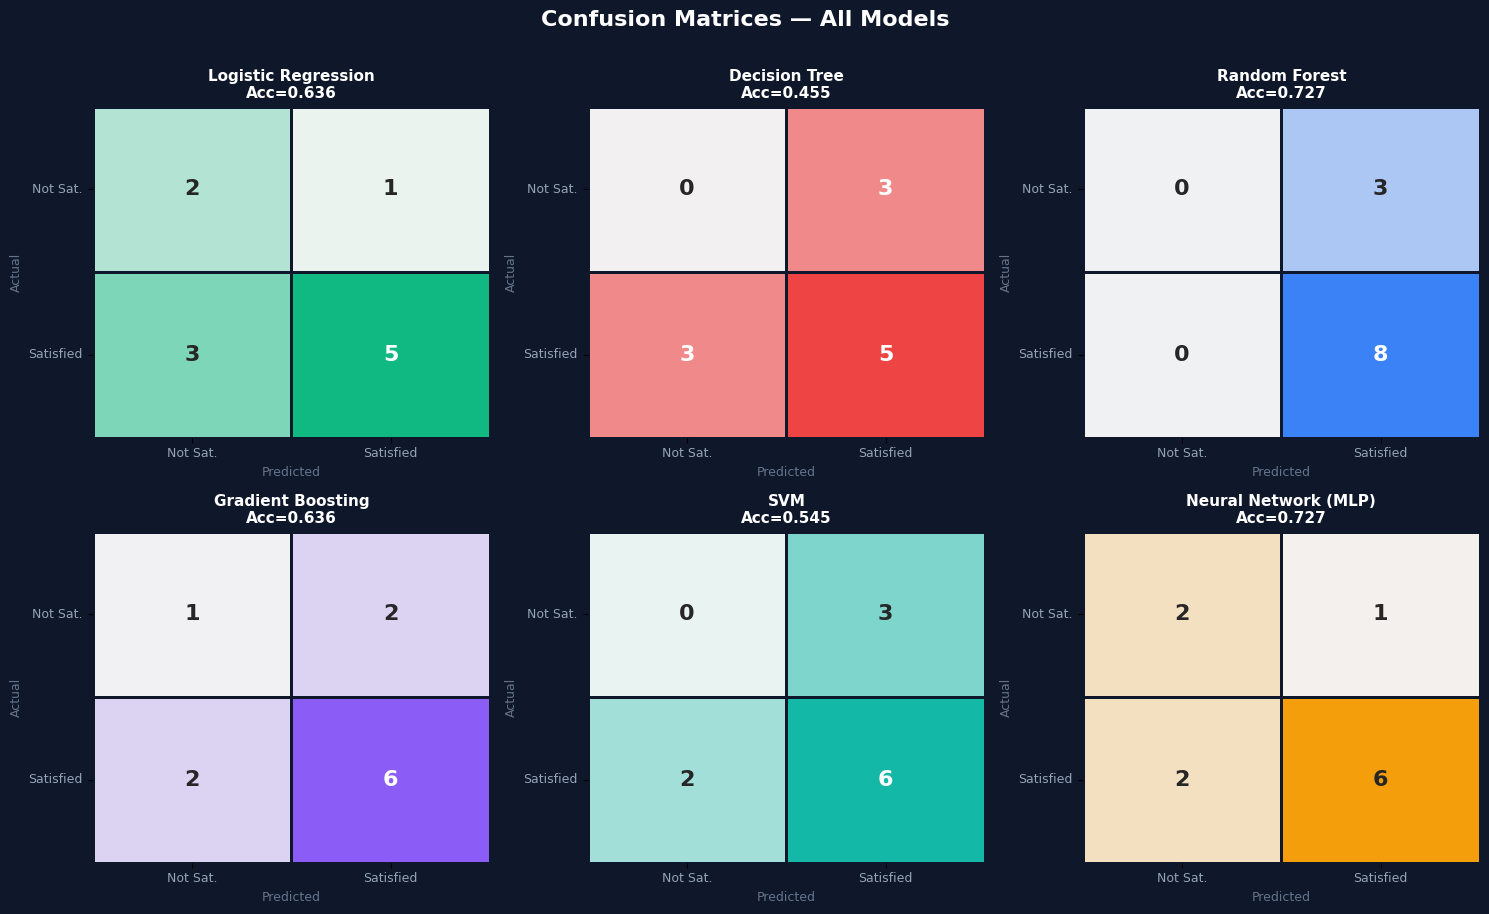

✅ Saved: confusion_matrices.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('#0F172A')
fig.suptitle('Confusion Matrices — All Models', fontsize=16,
             fontweight='bold', color='white', y=1.01)

for ax, (name, r) in zip(axes.flat, results.items()):
    ax.set_facecolor('#1E293B')
    cm = r['cm']
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(COLORS[name], as_cmap=True),
                cbar=False, linewidths=2, linecolor='#0F172A',
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}',
                 fontsize=11, color='white', fontweight='bold')
    ax.set_xticklabels(['Not Sat.', 'Satisfied'], color='#94A3B8', fontsize=9)
    ax.set_yticklabels(['Not Sat.', 'Satisfied'], color='#94A3B8', fontsize=9, rotation=0)
    ax.set_xlabel('Predicted', color='#64748B', fontsize=9)
    ax.set_ylabel('Actual',    color='#64748B', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('✅ Saved: confusion_matrices.png')

## Step 8: ROC Curves — All Models

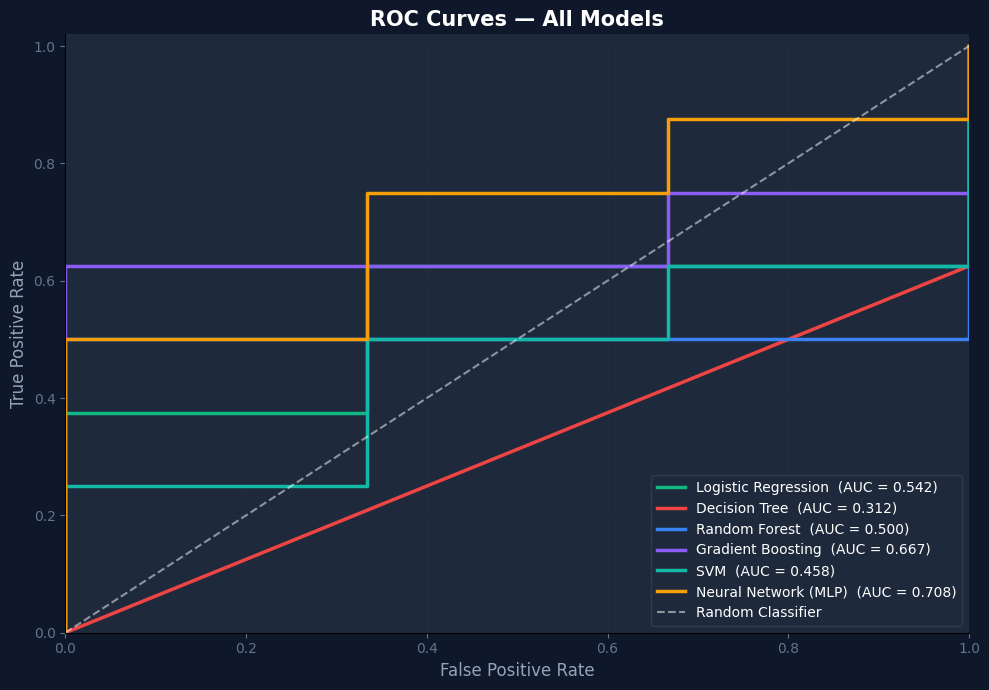

✅ Saved: roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0F172A')
ax.set_facecolor('#1E293B')

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=COLORS[name], lw=2.5,
            label=f"{name}  (AUC = {r['auc']:.3f})")

ax.plot([0,1],[0,1], 'w--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', color='#94A3B8', fontsize=12)
ax.set_ylabel('True Positive Rate',  color='#94A3B8', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=15, color='white', fontweight='bold')
ax.legend(facecolor='#1E293B', edgecolor='#334155', labelcolor='white',
          fontsize=10, loc='lower right')
ax.tick_params(colors='#64748B')
ax.grid(True, alpha=0.15, color='#334155')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('✅ Saved: roc_curves.png')

## Step 9: Model Accuracy Comparison

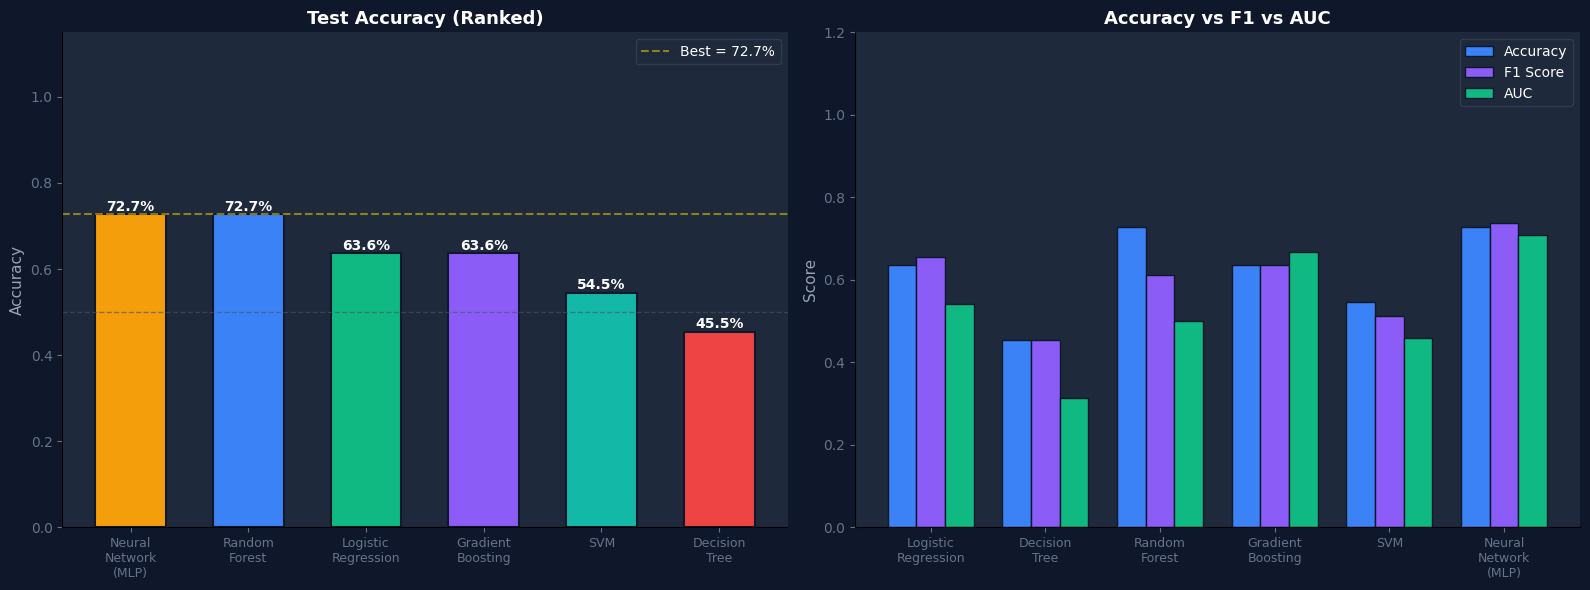

✅ Saved: model_comparison.png


In [10]:
names  = list(results.keys())
accs   = [results[n]['accuracy']  for n in names]
f1s    = [results[n]['f1']        for n in names]
cvs    = [results[n]['cv_mean']   for n in names]
aucs   = [results[n]['auc']       for n in names]
colors = [COLORS[n]               for n in names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0F172A')

# Left: Accuracy bar chart
ax = axes[0]
ax.set_facecolor('#1E293B')
sorted_idx = np.argsort(accs)[::-1]
s_names  = [names[i]  for i in sorted_idx]
s_accs   = [accs[i]   for i in sorted_idx]
s_colors = [colors[i] for i in sorted_idx]
bars = ax.bar(range(len(s_names)), s_accs, color=s_colors,
              edgecolor='#0F172A', linewidth=1.5, width=0.6)
for b, v in zip(bars, s_accs):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f'{v:.1%}',
            ha='center', fontsize=10, fontweight='bold', color='white')
ax.set_xticks(range(len(s_names)))
ax.set_xticklabels([n.replace(' ', '\n') for n in s_names],
                   fontsize=9, color='#94A3B8')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy', color='#94A3B8', fontsize=11)
ax.set_title('Test Accuracy (Ranked)', fontsize=13, color='white', fontweight='bold')
ax.axhline(0.5, color='#475569', lw=1, ls='--', alpha=0.6)
ax.axhline(max(accs), color='gold', lw=1.5, ls='--', alpha=0.5,
           label=f'Best = {max(accs):.1%}')
ax.legend(facecolor='#1E293B', edgecolor='#334155', labelcolor='white')
ax.tick_params(colors='#64748B')
ax.spines[['top','right']].set_visible(False)

# Right: Grouped bar Acc vs F1 vs AUC
ax2 = axes[1]
ax2.set_facecolor('#1E293B')
x = np.arange(len(names)); w = 0.25
ax2.bar(x-w, accs, w, label='Accuracy',  color='#3B82F6', edgecolor='#0F172A')
ax2.bar(x,   f1s,  w, label='F1 Score',  color='#8B5CF6', edgecolor='#0F172A')
ax2.bar(x+w, aucs, w, label='AUC',       color='#10B981', edgecolor='#0F172A')
ax2.set_xticks(x)
ax2.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9, color='#94A3B8')
ax2.set_ylim(0, 1.2)
ax2.set_title('Accuracy vs F1 vs AUC', fontsize=13, color='white', fontweight='bold')
ax2.set_ylabel('Score', color='#94A3B8', fontsize=11)
ax2.legend(facecolor='#1E293B', edgecolor='#334155', labelcolor='white', fontsize=10)
ax2.tick_params(colors='#64748B')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('✅ Saved: model_comparison.png')

## Step 10: Feature Importance (Random Forest & Gradient Boosting)

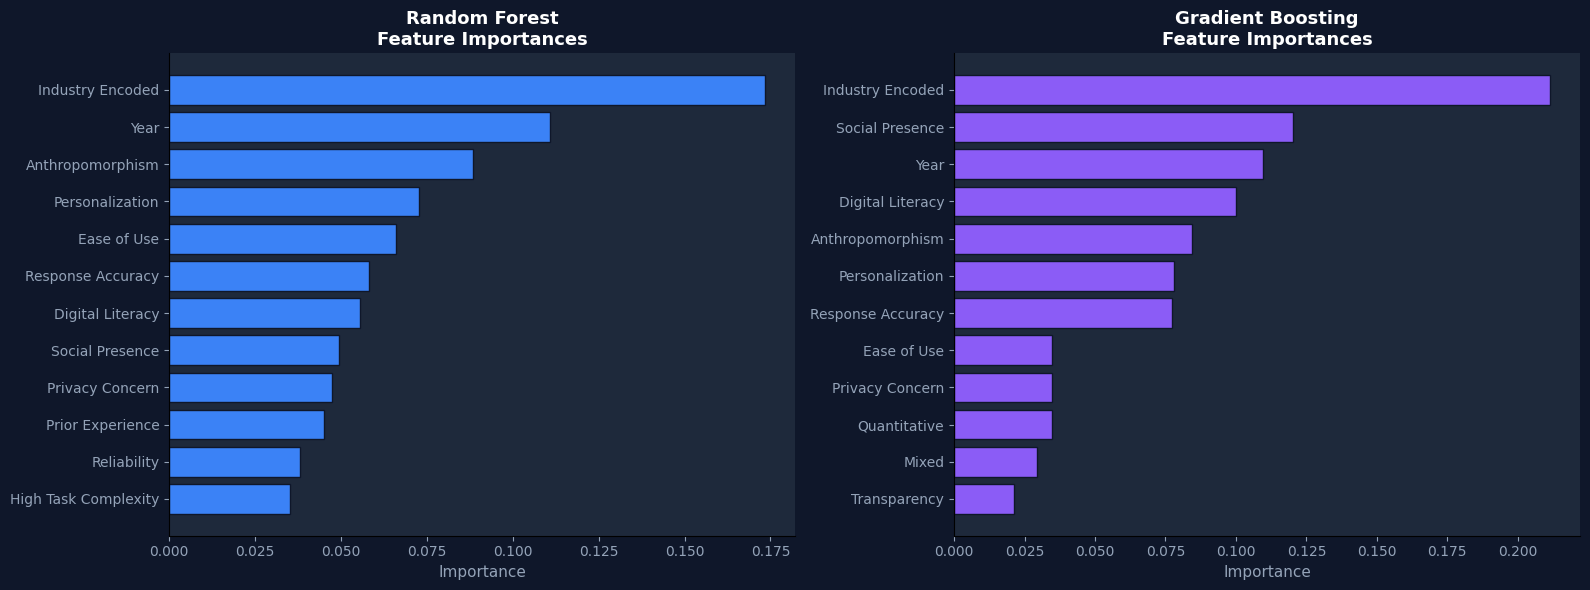

✅ Saved: feature_importance.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0F172A')

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    ax.set_facecolor('#1E293B')
    model = results[model_name]['model']
    imp   = model.feature_importances_
    idx   = np.argsort(imp)[::-1]
    top_n = 12
    ax.barh(
        [feature_cols[i].replace('_', ' ') for i in idx[:top_n]][::-1],
        imp[idx[:top_n]][::-1],
        color=COLORS[model_name], edgecolor='#0F172A'
    )
    ax.set_title(f'{model_name}\nFeature Importances',
                 fontsize=13, color='white', fontweight='bold')
    ax.set_xlabel('Importance', color='#94A3B8', fontsize=11)
    ax.tick_params(colors='#94A3B8', labelsize=10)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('✅ Saved: feature_importance.png')

## Step 11: Cross-Validation Scores (5-Fold)

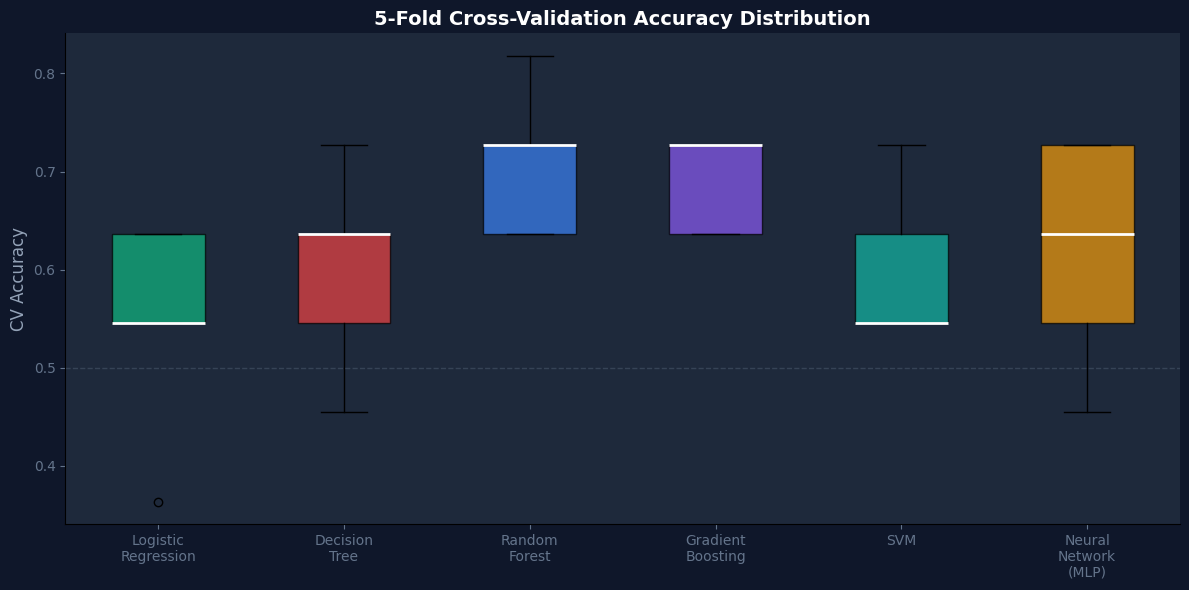

✅ Saved: cv_scores.png


In [12]:
cv_all = {}
for name, r in results.items():
    cv_all[name] = cross_val_score(
        r['model'], X_scaled, y, cv=5, scoring='accuracy')

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0F172A')
ax.set_facecolor('#1E293B')

bp = ax.boxplot([cv_all[n] for n in names],
                patch_artist=True, notch=False,
                medianprops={'color':'white','linewidth':2})
for patch, name in zip(bp['boxes'], names):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(names)+1))
ax.set_xticklabels([n.replace(' ', '\n') for n in names],
                   fontsize=10, color='#94A3B8')
ax.set_ylabel('CV Accuracy', color='#94A3B8', fontsize=12)
ax.set_title('5-Fold Cross-Validation Accuracy Distribution',
             fontsize=14, color='white', fontweight='bold')
ax.axhline(0.5, color='#475569', lw=1, ls='--', alpha=0.6)
ax.tick_params(colors='#64748B')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('cv_scores.png', dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('✅ Saved: cv_scores.png')

## Step 12: Detailed Report — Best Model

In [13]:
best = max(results, key=lambda n: results[n]['accuracy'])
print(f'🏆 Best Model: {best}')
print(f'   Test Accuracy : {results[best]["accuracy"]:.4f}')
print(f'   F1 Score      : {results[best]["f1"]:.4f}')
print(f'   AUC           : {results[best]["auc"]:.4f}')
print(f'   CV Mean±Std   : {results[best]["cv_mean"]:.4f} ± {results[best]["cv_std"]:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, results[best]['y_pred'],
      target_names=['Not Satisfied', 'Satisfied']))

🏆 Best Model: Random Forest
   Test Accuracy : 0.7273
   F1 Score      : 0.6124
   AUC           : 0.5000
   CV Mean±Std   : 0.7091 ± 0.0680

Classification Report:
               precision    recall  f1-score   support

Not Satisfied       0.00      0.00      0.00         3
    Satisfied       0.73      1.00      0.84         8

     accuracy                           0.73        11
    macro avg       0.36      0.50      0.42        11
 weighted avg       0.53      0.73      0.61        11



## Step 13: Final Ranking & Conclusion

In [14]:
print('=' * 60)
print('  FINAL MODEL RANKING (by Test Accuracy)')
print('=' * 60)
ranked = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, r) in enumerate(ranked, 1):
    medal = ['🥇','🥈','🥉'][rank-1] if rank <= 3 else f' {rank}.'
    print(f'{medal}  {name:<25} Acc={r["accuracy"]:.3f}  '
          f'F1={r["f1"]:.3f}  AUC={r["auc"]:.3f}  CV={r["cv_mean"]:.3f}')
print('=' * 60)
print(f'\n✅ RECOMMENDED MODEL: {ranked[0][0]}')
print(f'   Reason: Highest test accuracy ({ranked[0][1]["accuracy"]:.1%}) '
       f'with stable CV accuracy ({ranked[0][1]["cv_mean"]:.1%})')

  FINAL MODEL RANKING (by Test Accuracy)
🥇  Random Forest             Acc=0.727  F1=0.612  AUC=0.500  CV=0.709
🥈  Neural Network (MLP)      Acc=0.727  F1=0.738  AUC=0.708  CV=0.618
🥉  Logistic Regression       Acc=0.636  F1=0.656  AUC=0.542  CV=0.545
 4.  Gradient Boosting         Acc=0.636  F1=0.636  AUC=0.667  CV=0.691
 5.  SVM                       Acc=0.545  F1=0.513  AUC=0.458  CV=0.600
 6.  Decision Tree             Acc=0.455  F1=0.455  AUC=0.312  CV=0.600

✅ RECOMMENDED MODEL: Random Forest
   Reason: Highest test accuracy (72.7%) with stable CV accuracy (70.9%)
